In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import random

np.set_printoptions(suppress=True, precision=4)
pd.set_option('display.float_format', lambda x: '%.4f' % x)

config = {
    'tickers': ['AAPL', 'MSFT', 'GOOGL'],
    'start_date': "2020-01-01",
    'end_date': "2024-01-01",
    'sequence_length': 5,
    'features': ['Open', 'High', 'Low', 'Close'],
    'random_seed': 35,
    'd_model': 16,         # Embedding and transformer dimension
    'n_heads': 1,          # Number of attention heads
    'dropout': 0.1,        # Dropout rate
    'n_layers': 1,         # Transformer layers
    'batch_size': 16,       # Batch size
    'lr': 0.0001,          # Learning rate
    'epochs': 100,           # Training epochs
    'max_day_of_week': 7,  # 7 days in a week
    'max_month': 12, 
    'print_interval': 30
}

seed = config['random_seed']
torch.manual_seed(seed)  # Seed for PyTorch
np.random.seed(seed)     # Seed for NumPy
random.seed(seed)        # Seed for Python's random library (if needed)


In [2]:

# Download and inspect raw data
raw_data = {}
columns = ['Open', 'High', 'Low', 'Close', 'Volume']

for ticker in config['tickers']:
    print(f"\nProcessing {ticker}...")
    
    # Download data
    df = yf.download(ticker, start=config['start_date'], end=config['end_date'], progress=False)
    raw_data[ticker] = df[columns]
    
#     # Print data info
#     print(f"\nShape of {ticker} data:", df[columns].shape)
#     print(f"\nFirst few rows of {ticker} data:")
#     display(df[columns].head())
    
    # Create two separate figures: one for prices, one for volume
    # Price Plot
    # plt.figure(figsize=(8, 3))
    # for col in config['features']:
    #     plt.plot(df.index, df[col], label=col, alpha=0.8)
    # plt.title(f'{ticker} OHLC Prices')
    # plt.xlabel('Date')
    # plt.ylabel('Price ($)')
    # plt.legend()
    # plt.grid(True)
    # plt.tight_layout()
    # plt.show()
    
    # # Volume Plot
    # plt.figure(figsize=(8, 3))
    # plt.bar(df.index, df['Volume'], alpha=0.8)
    # plt.title(f'{ticker} Trading Volume')
    # plt.xlabel('Date')
    # plt.ylabel('Volume')
    # plt.grid(True)
    # plt.tight_layout()
    # plt.show()
    
    # # Print statistics
    # print(f"\nStatistics for {ticker}:")
    # display(df[columns].describe())
    
    # # Show basic statistical plots
    # plt.figure(figsize=(8, 3))
    
    # # Box plot for price columns
    # plt.subplot(2, 1, 1)
    # df[columns].boxplot()
    # plt.title(f'{ticker} Price Distribution')
    # plt.ylabel('Price ($)')
    
    # # Volume distribution
    # plt.subplot(2, 1, 2)
    # sns.histplot(df['Volume'], bins=50)
    # plt.title(f'{ticker} Volume Distribution')
    # plt.xlabel('Volume')
    
    # plt.tight_layout()
    # plt.show()


Processing AAPL...

Processing MSFT...

Processing GOOGL...


In [3]:
raw_data

{'AAPL':                               Open     High      Low    Close     Volume
 Date                                                                    
 2020-01-02 00:00:00+00:00  74.0600  75.1500  73.7975  75.0875  135480400
 2020-01-03 00:00:00+00:00  74.2875  75.1450  74.1250  74.3575  146322800
 2020-01-06 00:00:00+00:00  73.4475  74.9900  73.1875  74.9500  118387200
 2020-01-07 00:00:00+00:00  74.9600  75.2250  74.3700  74.5975  108872000
 2020-01-08 00:00:00+00:00  74.2900  76.1100  74.2900  75.7975  132079200
 ...                            ...      ...      ...      ...        ...
 2023-12-22 00:00:00+00:00 195.1800 195.4100 192.9700 193.6000   37122800
 2023-12-26 00:00:00+00:00 193.6100 193.8900 192.8300 193.0500   28919300
 2023-12-27 00:00:00+00:00 192.4900 193.5000 191.0900 193.1500   48087700
 2023-12-28 00:00:00+00:00 194.1400 194.6600 193.1700 193.5800   34049900
 2023-12-29 00:00:00+00:00 193.9000 194.4000 191.7300 192.5300   42628800
 
 [1006 rows x 5 columns],
 '

In [4]:
def create_sequences_single_stock(stock_data: pd.DataFrame, seq_length: int, ticker_id: int) -> tuple:
    """
    Create sequences from a single stock's data and include ticker_id.
    """
    # # Separate OHLC and Volume
    # ohlc_data = stock_data[['Open', 'High', 'Low', 'Close']].values
    # volume_data = stock_data[['Volume']].values
    
    # # Create sequences
    # sequences_ohlc = []
    # sequences_volume = []
    # ticker_ids = []  # Track ticker IDs for each sequence
    
    # for i in range(len(stock_data) - seq_length + 1):
    #     sequences_ohlc.append(ohlc_data[i:i + seq_length])
    #     sequences_volume.append(volume_data[i:i + seq_length])
    #     ticker_ids.append(ticker_id)  # Append the ticker_id for each sequence
    
    # sequences_ohlc = np.array(sequences_ohlc)
    # sequences_volume = np.array(sequences_volume)
    # ticker_ids = np.array(ticker_ids)  # Convert to a numpy array for consistency
    
    # return sequences_ohlc, sequences_volume, ticker_ids
    
    ohlc_data = stock_data[config['features']].values
    volume_data = stock_data[['Volume']].values
    dates = stock_data.index

    sequences_ohlc, sequences_volume, ticker_ids, date_info = [], [], [], []

    for i in range(len(stock_data) - seq_length + 1):
        sequences_ohlc.append(ohlc_data[i:i + seq_length])
        sequences_volume.append(volume_data[i:i + seq_length])
        ticker_ids.append(ticker_id)

        day_of_week = np.array([date.weekday() for date in dates[i:i + seq_length]])
        month = np.array([date.month for date in dates[i:i + seq_length]])
        date_info.append(np.stack([day_of_week, month], axis=1))

    return np.array(sequences_ohlc), np.array(sequences_volume), np.array(ticker_ids), np.array(date_info)



ticker_to_id = {ticker: idx for idx, ticker in enumerate(config['tickers'])}





In [5]:

# Create sequences for each ticker
sequences = {}
for ticker in config['tickers']:
    ticker_id = ticker_to_id[ticker]
    sequences_ohlc, sequences_volume, ticker_ids, date_info = create_sequences_single_stock(
        raw_data[ticker], 
        config['sequence_length'],
        ticker_id
    )
    
    sequences[ticker] = {
        'sequences_ohlc': sequences_ohlc,
        'sequences_volume': sequences_volume,
        'ticker_ids': ticker_ids,
        'date_info': date_info 
    }
    # print(sequences)
    print(f"\nStored sequences for ticker {ticker}: {sequences_ohlc.shape}")
    print(f"\nStored sequences for ticker {ticker}: {sequences_ohlc}")



Stored sequences for ticker AAPL: (1002, 5, 4)

Stored sequences for ticker AAPL: [[[ 74.06    75.15    73.7975  75.0875]
  [ 74.2875  75.145   74.125   74.3575]
  [ 73.4475  74.99    73.1875  74.95  ]
  [ 74.96    75.225   74.37    74.5975]
  [ 74.29    76.11    74.29    75.7975]]

 [[ 74.2875  75.145   74.125   74.3575]
  [ 73.4475  74.99    73.1875  74.95  ]
  [ 74.96    75.225   74.37    74.5975]
  [ 74.29    76.11    74.29    75.7975]
  [ 76.81    77.6075  76.55    77.4075]]

 [[ 73.4475  74.99    73.1875  74.95  ]
  [ 74.96    75.225   74.37    74.5975]
  [ 74.29    76.11    74.29    75.7975]
  [ 76.81    77.6075  76.55    77.4075]
  [ 77.65    78.1675  77.0625  77.5825]]

 ...

 [[196.9    197.68   194.83   194.83  ]
  [196.1    197.08   193.5    194.68  ]
  [195.18   195.41   192.97   193.6   ]
  [193.61   193.89   192.83   193.05  ]
  [192.49   193.5    191.09   193.15  ]]

 [[196.1    197.08   193.5    194.68  ]
  [195.18   195.41   192.97   193.6   ]
  [193.61   193.89   19

In [6]:
raw_data['AAPL'].head()

,Open,High,Low,Close,Volume
Date,,,,,
2020-01-02 00:00:00+00:00,74.0600,75.1500,73.7975,75.0875,135480400
2020-01-03 00:00:00+00:00,74.2875,75.1450,74.1250,74.3575,146322800
2020-01-06 00:00:00+00:00,73.4475,74.9900,73.1875,74.9500,118387200
2020-01-07 00:00:00+00:00,74.9600,75.2250,74.3700,74.5975,108872000
2020-01-08 00:00:00+00:00,74.2900,76.1100,74.2900,75.7975,132079200


In [7]:
config['tickers']

['AAPL', 'MSFT', 'GOOGL']

In [8]:
processed_data = {}
for ticker in sequences:
    # Get the raw OHLC and volume sequences
    sequences_ohlc = sequences[ticker]['sequences_ohlc']
    sequences_volume = sequences[ticker]['sequences_volume']
    ticker_ids = sequences[ticker]['ticker_ids']
    
    # Step 1: Compute original mean and std for normalization (raw data)
    ohlc_mean = sequences_ohlc.mean(axis=(0, 1))
    ohlc_std = sequences_ohlc.std(axis=(0, 1))
    vol_mean = sequences_volume.mean()
    vol_std = sequences_volume.std()
    
    # Step 2: Normalize the data
    norm_ohlc = (sequences_ohlc - ohlc_mean) / (ohlc_std + 1e-8)
    norm_volume = (sequences_volume - vol_mean) / (vol_std + 1e-8)
    
    # Step 3: Store normalized data and raw normalization parameters for denormalization
    processed_data[ticker] = {
        'sequences_ohlc': sequences_ohlc,           # Original raw OHLC sequences
        'sequences_volume': sequences_volume,       # Original raw Volume sequences
        'norm_ohlc': norm_ohlc,                     # Normalized OHLC sequences
        'norm_volume': norm_volume,                 # Normalized Volume sequences
        'norm_params': {                            # Store raw params for denormalization
            'ohlc_mean': ohlc_mean,
            'ohlc_std': ohlc_std,
            'vol_mean': vol_mean,
            'vol_std': vol_std
        },
        'ticker_ids': ticker_ids,
        'date_info': date_info 
    }
    
    print(f"\nStored normalization parameters for {ticker} (original data):")
    print("OHLC Mean:", ohlc_mean)
    print("OHLC Std Dev:", ohlc_std)
    print("Volume Mean:", vol_mean)
    print("Volume Std Dev:", vol_std)



Stored normalization parameters for AAPL (original data):
OHLC Mean: [140.7026 142.3519 139.1681 140.8357]
OHLC Std Dev: [33.1425 33.2649 33.0156 33.1511]
Volume Mean: 99002958.28343314
Volume Std Dev: 54389267.43152623

Stored normalization parameters for MSFT (original data):
OHLC Mean: [262.6528 265.4983 259.7806 262.7637]
OHLC Std Dev: [54.3031 54.3858 54.0678 54.2761]
Volume Mean: 30701202.215568863
Volume Std Dev: 12994356.975612214

Stored normalization parameters for GOOGL (original data):
OHLC Mean: [107.8169 109.1043 106.6075 107.8839]
OHLC Std Dev: [25.0995 25.2088 24.9171 25.0501]
Volume Mean: 34539792.43512974
Volume Std Dev: 15012417.997180486


Normalization parameters for denormalization:
{'ohlc_mean': array([140.7026, 142.3519, 139.1681, 140.8357]), 'ohlc_std': array([33.1425, 33.2649, 33.0156, 33.1511]), 'vol_mean': 99002958.28343314, 'vol_std': 54389267.43152623}
Shape of norm_seq: (5, 4)
Shape of data['norm_volume'][0]: (5, 1)
Original vs Denormalized comparison:

Original sequence first 3 timesteps:
[[74.06   75.15   73.7975 75.0875]
 [74.2875 75.145  74.125  74.3575]
 [73.4475 74.99   73.1875 74.95  ]]

Denormalized sequence first 3 timesteps:
[[74.06   75.15   73.7975 75.0875]
 [74.2875 75.145  74.125  74.3575]
 [73.4475 74.99   73.1875 74.95  ]]

Absolute difference:
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]

Original volume first 3 timesteps:
[[135480400]
 [146322800]
 [118387200]
 [108872000]
 [132079200]]

Denormalized volume first 3 timesteps:
[[[1.3548e+08]
  [1.4632e+08]
  [1.1839e+08]
  [1.0887e+08]
  [1.3208e+08]]]

Absolute difference volume:
[[[0.]
  [0.]
  [0.]
  [0.]
  [0.]]]


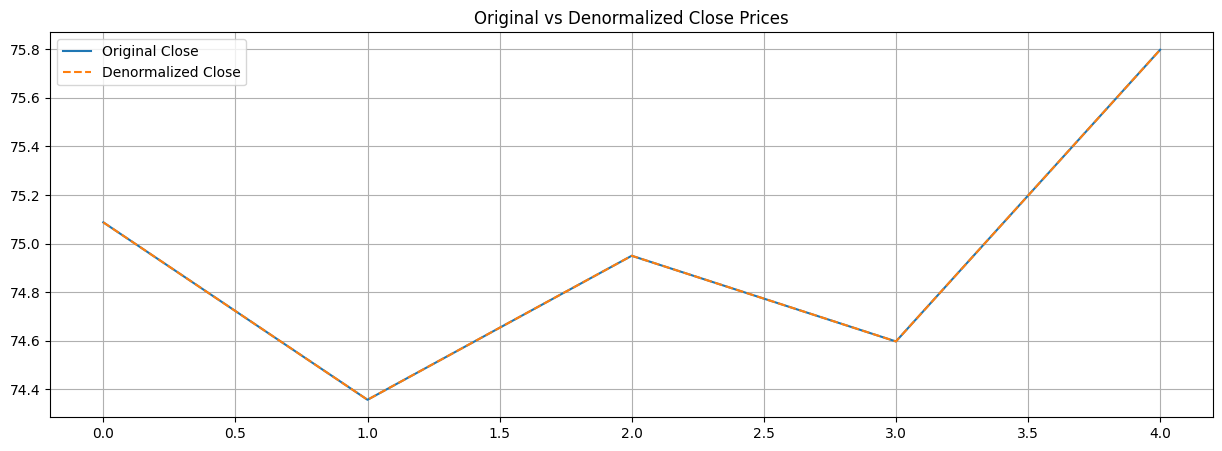

In [ ]:
def denormalize_stock_data(norm_ohlc: np.ndarray, norm_volume: np.ndarray, 
                          norm_params: dict) -> tuple:
    """
    Denormalize data back to original scale
    """
    denorm_ohlc = (norm_ohlc * norm_params['ohlc_std']) + norm_params['ohlc_mean']
    denorm_volume = (norm_volume * norm_params['vol_std']) + norm_params['vol_mean']
    return denorm_ohlc, denorm_volume

# Test denormalization for one stock
ticker = 'AAPL'
data = processed_data[ticker]

print("Normalization parameters for denormalization:")
print(data['norm_params'])

original_seq = data['sequences_ohlc'][0]  # First sequence
original_vol = data['sequences_volume'][0]  # First sequence
norm_seq = data['norm_ohlc'][0]

print("Shape of norm_seq:", norm_seq.shape)
print("Shape of data['norm_volume'][0]:", data['norm_volume'][0].shape)

denorm_seq, denorm_volume = denormalize_stock_data(
    norm_seq[np.newaxis], 
    data['norm_volume'][0][np.newaxis],
    data['norm_params']
)

print("Original vs Denormalized comparison:")
print("\nOriginal sequence first 3 timesteps:")
print(original_seq[:3])
print("\nDenormalized sequence first 3 timesteps:")
print(denorm_seq[0, :3])
print("\nAbsolute difference:")
print(np.abs(original_seq[:3] - denorm_seq[0, :3]))

print("\nOriginal volume first 3 timesteps:")
print(original_vol)
print("\nDenormalized volume first 3 timesteps:")
print(denorm_volume)
print("\nAbsolute difference volume:")
print(np.abs(original_vol - denorm_volume))

# Visualize
plt.figure(figsize=(15, 5))
plt.plot(original_seq[:, 3], label='Original Close')  # Close prices
plt.plot(denorm_seq[0, :, 3], '--', label='Denormalized Close')
plt.title('Original vs Denormalized Close Prices')
plt.legend()
plt.grid(True)
plt.show()

In [10]:
import math

# This assumes you have already processed data with ticker IDs and date information
training_data = []

# Process each ticker and prepare data with day_of_week and month
for ticker in config['tickers']:
    ticker_id = ticker_to_id[ticker]
    norm_ohlc = processed_data[ticker]['norm_ohlc']   # Normalized OHLC sequences
    date_info = processed_data[ticker]['date_info']   # Date information (day of week, month)

    # Prepare each sequence with additional info for training
    for i in range(norm_ohlc.shape[0]):
        sequence = norm_ohlc[i]  # One OHLC sequence
        ticker_id_tensor = torch.tensor([ticker_id])  # Convert ticker_id to tensor
        day_of_week = torch.tensor(date_info[i, :, 0])  # Day of week for each timestep
        month = torch.tensor(date_info[i, :, 1])        # Month for each timestep

        # Append to training data list
        training_data.append({
            'norm_ohlc': torch.FloatTensor(sequence),  # Normalized OHLC sequence
            'ticker_ids': ticker_id_tensor,            # Ticker ID
            'day_of_week': day_of_week,                # Day of week for each step
            'month': month                             # Month for each step
        })

# Convert to DataLoader format for batching
from torch.utils.data import DataLoader

batch_size = config['batch_size']
train_loader = DataLoader(training_data, batch_size=batch_size, shuffle=True)


In [11]:
import math

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len):
        super(PositionalEncoding, self).__init__()
        self.encoding = torch.zeros(max_len, d_model)
        
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * -(math.log(10000.0) / d_model))
        
        self.encoding[:, 0::2] = torch.sin(position * div_term)
        self.encoding[:, 1::2] = torch.cos(position * div_term)
        self.encoding = self.encoding.unsqueeze(0)  # Shape: [1, max_len, d_model]

    def forward(self, x):
        x = x + self.encoding[:, :x.size(1)]
        return x


class TransformerGenerator(nn.Module):
    def __init__(self, config, num_tickers):
        super(TransformerGenerator, self).__init__()
        self.d_model = config['d_model']
        
        # Embedding layers
        self.ticker_embedding = nn.Embedding(num_tickers, self.d_model)
        self.day_embedding = nn.Embedding(config['max_day_of_week'], self.d_model)
        self.month_embedding = nn.Embedding(config['max_month'] + 1, self.d_model)
        
        # Project input to d_model dimension
        self.input_projection = nn.Linear(len(config['features']), self.d_model)  # Ensure src matches d_model
        
        # Positional Encoding
        self.pos_encoder = PositionalEncoding(self.d_model, max_len=config['sequence_length'])
        
        # Transformer layers
        encoder_layers = nn.TransformerEncoderLayer(d_model=self.d_model, nhead=config['n_heads'], dropout=config['dropout'])
        self.transformer_encoder = nn.TransformerEncoder(encoder_layers, num_layers=config['n_layers'])
        
        # Output layer to map back to feature space
        self.fc_out = nn.Linear(self.d_model, len(config['features']))
    
    def forward(self, src, ticker_ids, day_of_week, month):
        # Project src to d_model dimension
        src = self.input_projection(src)
        
        # Embeddings
        ticker_embeds = self.ticker_embedding(ticker_ids)
        day_embeds = self.day_embedding(day_of_week)
        month_embeds = self.month_embedding(month)
        
        # Add embeddings to input sequence
        src = src + ticker_embeds + day_embeds + month_embeds
        src = self.pos_encoder(src)
        
        # Transformer and final output
        output = self.transformer_encoder(src)
        output = self.fc_out(output)  # Map back to feature space
        return output


class TransformerDiscriminator(nn.Module):
    def __init__(self, config, num_tickers):
        super(TransformerDiscriminator, self).__init__()
        d_model = config['d_model']
        
        # Embedding layers
        self.ticker_embedding = nn.Embedding(num_tickers, d_model)
        self.day_embedding = nn.Embedding(config['max_day_of_week'], d_model)
        self.month_embedding = nn.Embedding(config['max_month'] + 1, d_model)

        # Project input data to d_model dimension if needed
        self.input_projection = nn.Linear(len(config['features']), d_model)  # Project features to d_model

        # Positional Encoding
        self.pos_encoder = PositionalEncoding(d_model, config['sequence_length'])

        # Transformer layers
        encoder_layers = nn.TransformerEncoderLayer(d_model=d_model, nhead=config['n_heads'], dropout=config['dropout'])
        self.transformer_encoder = nn.TransformerEncoder(encoder_layers, num_layers=config['n_layers'])

        # Output layer
        self.fc_out = nn.Linear(d_model, 1)
    
    def forward(self, src, ticker_ids, day_of_week, month):
        # Project input to d_model dimension
        src = self.input_projection(src)

        # Embeddings
        ticker_embeds = self.ticker_embedding(ticker_ids)
        day_embeds = self.day_embedding(day_of_week)
        # print('month', month)
        month_embeds = self.month_embedding(month)
        
        # Add embeddings to input sequence
        src = src + ticker_embeds + day_embeds + month_embeds
        src = self.pos_encoder(src)
        
        # Transformer and final output
        output = self.transformer_encoder(src)
        output = self.fc_out(output.mean(dim=1))  # Aggregate output across sequence
        return torch.sigmoid(output)  # Sigmoid for binary classification


# Instantiate Models
num_tickers = len(config['tickers'])
# Initialization of the TransformerDiscriminator
sequence_length = config['sequence_length']  # Ensure consistency here
d_model = config['d_model']
# Define models with the correct parameters from config

discriminator = TransformerDiscriminator(config, num_tickers)
generator = TransformerGenerator(config, num_tickers)



# Define Optimizers
optimizer_G = torch.optim.Adam(generator.parameters(), lr=config['lr'])
optimizer_D = torch.optim.Adam(discriminator.parameters(), lr=config['lr'])

# Define Loss Function
adversarial_loss = nn.BCELoss()




/Users/lucijagregov/Documents/gan_finance/.venv_finance/lib/python3.11/site-packages/torch/nn/modules/transformer.py:286: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


In [12]:
# Define models
num_tickers = len(config['tickers'])
generator = TransformerGenerator(config, num_tickers)
discriminator = TransformerDiscriminator(config, num_tickers)

# Define optimizer and loss
optimizer_G = torch.optim.Adam(generator.parameters(), lr=config['lr'])
optimizer_D = torch.optim.Adam(discriminator.parameters(), lr=config['lr'])
adversarial_loss = nn.BCELoss()

# Training loop
for epoch in range(config['epochs']):
    for batch in train_loader:
        # Extract batch data
        real_sequences = batch['norm_ohlc']         # Normalized OHLC data
        ticker_ids = batch['ticker_ids']            # Ticker IDs for each sequence
        day_of_week = batch['day_of_week']          # Day of the week
        month = batch['month']                      # Month
        
        # print("Day of Week Sample:", day_of_week)
        # print("Month Sample:", month)

        if day_of_week.max() > 6 or day_of_week.min() < 0:
            print("Warning: day_of_week values are out of expected range (0-6).")

        if month.max() > 12 or month.min() < 1:
            print("Warning: month values are out of expected range (1-12).")


        # Convert to appropriate dimensions if needed
        batch_size, seq_len, feature_dim = real_sequences.size()

        # Set real and fake labels
        real_labels = torch.ones(batch_size, 1)
        fake_labels = torch.zeros(batch_size, 1)

        # Train Discriminator on Real Data
        real_output = discriminator(real_sequences, ticker_ids, day_of_week, month)
        real_loss = adversarial_loss(real_output, real_labels)

        # Train Discriminator on Fake Data
        noise = torch.randn(batch_size, seq_len, feature_dim)  # Example noise
        fake_sequences = generator(noise, ticker_ids, day_of_week, month)
        fake_output = discriminator(fake_sequences.detach(), ticker_ids, day_of_week, month)
        fake_loss = adversarial_loss(fake_output, fake_labels)

        # Backpropagation and optimization
        optimizer_D.zero_grad()
        d_loss = real_loss + fake_loss
        d_loss.backward()
        optimizer_D.step()

        # Train Generator
        generated_output = discriminator(fake_sequences, ticker_ids, day_of_week, month)
        g_loss = adversarial_loss(generated_output, real_labels)

        optimizer_G.zero_grad()
        g_loss.backward()
        optimizer_G.step()
        
    if epoch % config['print_interval'] == 0:
        print(f"Epoch {epoch}/{config['epochs']}, Discriminator Loss: {d_loss.item()}, Generator Loss: {g_loss.item()}")


/Users/lucijagregov/Documents/gan_finance/.venv_finance/lib/python3.11/site-packages/torch/nn/modules/transformer.py:286: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


Epoch 0/100, Discriminator Loss: 1.4462472200393677, Generator Loss: 0.774875819683075


KeyboardInterrupt: 


Evaluating for ticker: AAPL


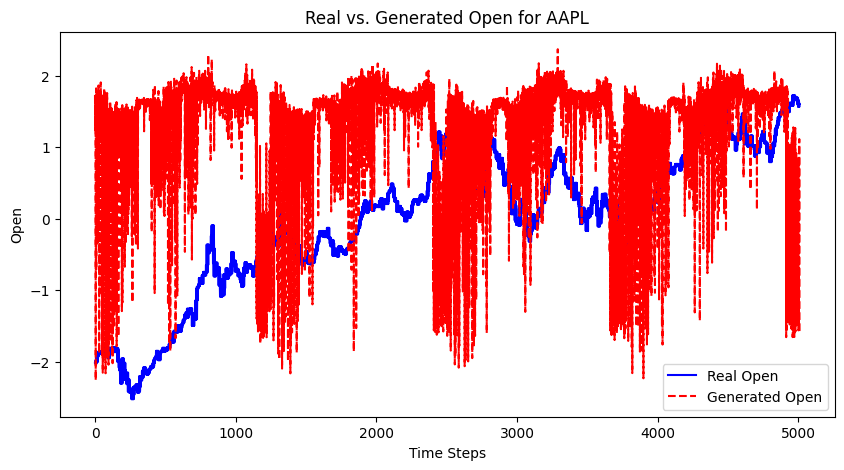

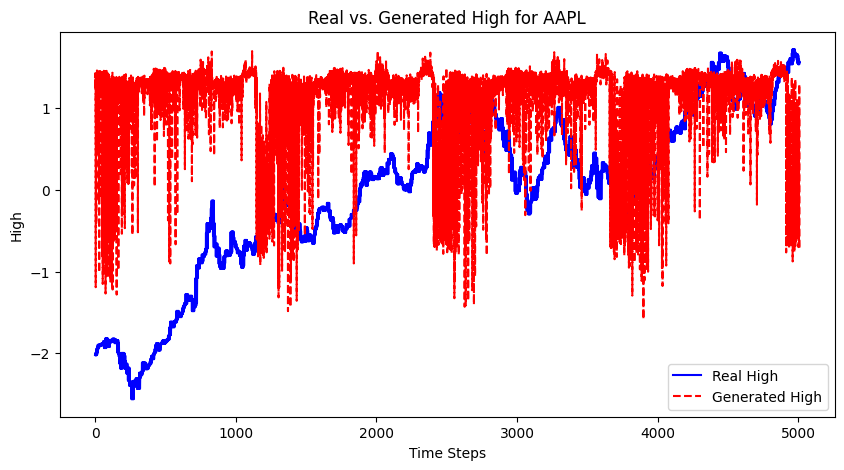

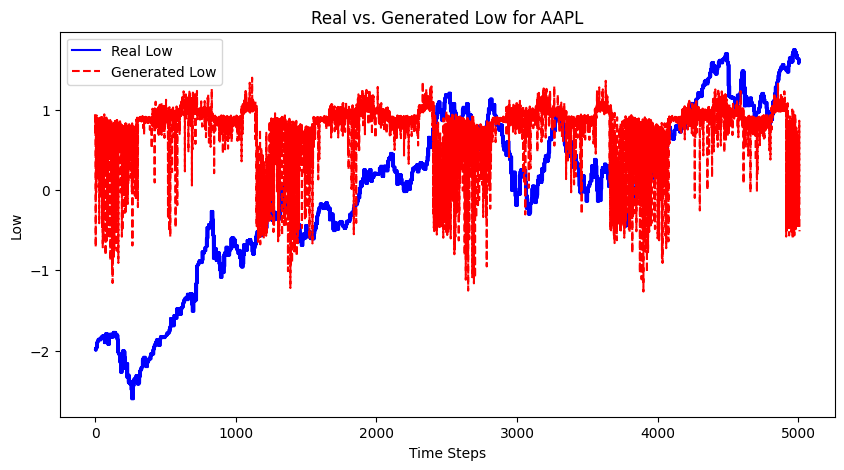

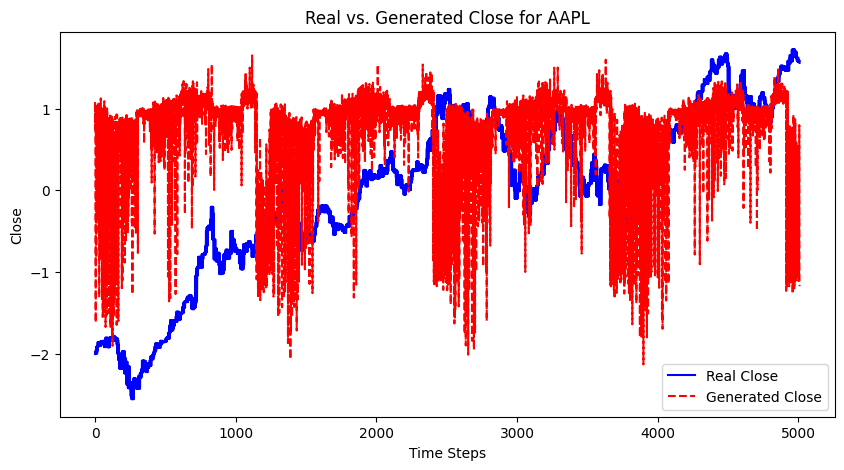

Mean Absolute Error for AAPL:
  Open: 1.5688
  High: 1.2761
  Low: 1.0062
  Close: 1.0712

Evaluating for ticker: MSFT


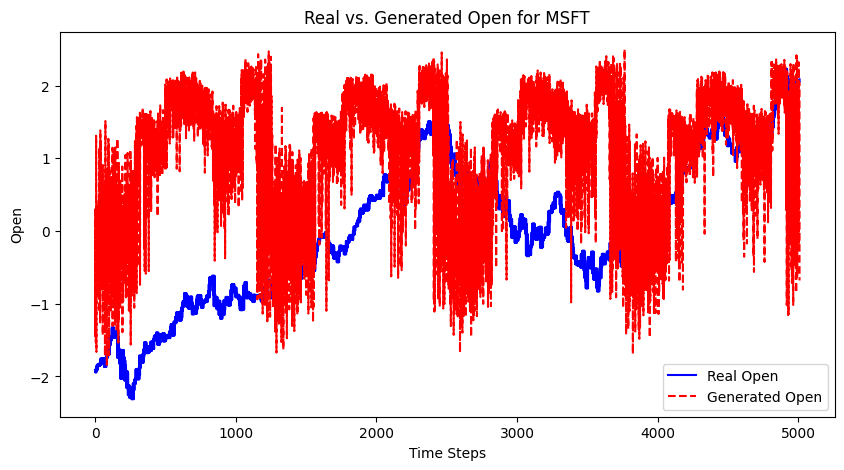

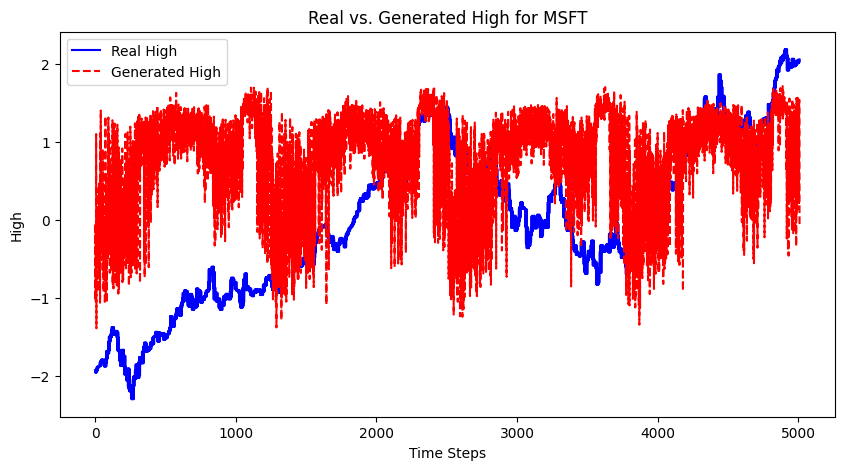

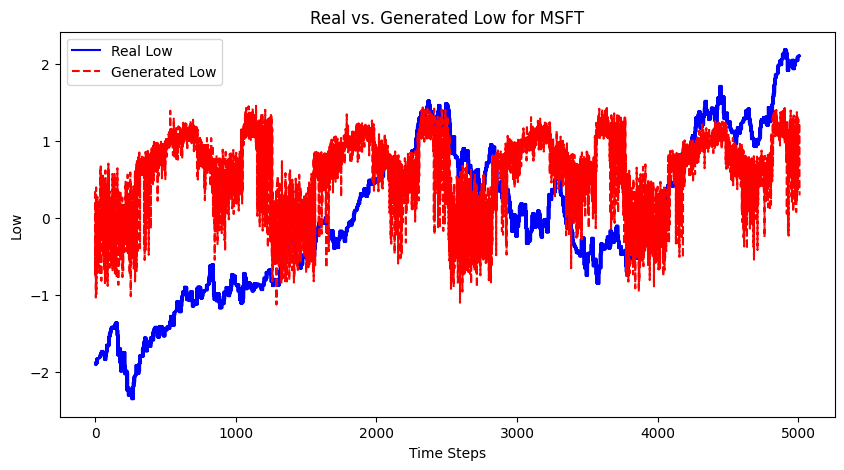

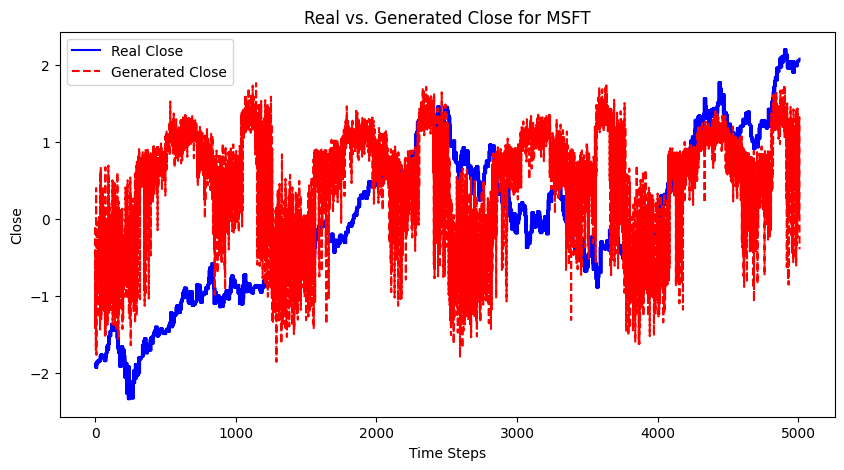

Mean Absolute Error for MSFT:
  Open: 1.3243
  High: 1.0521
  Low: 0.9473
  Close: 0.9658

Evaluating for ticker: GOOGL


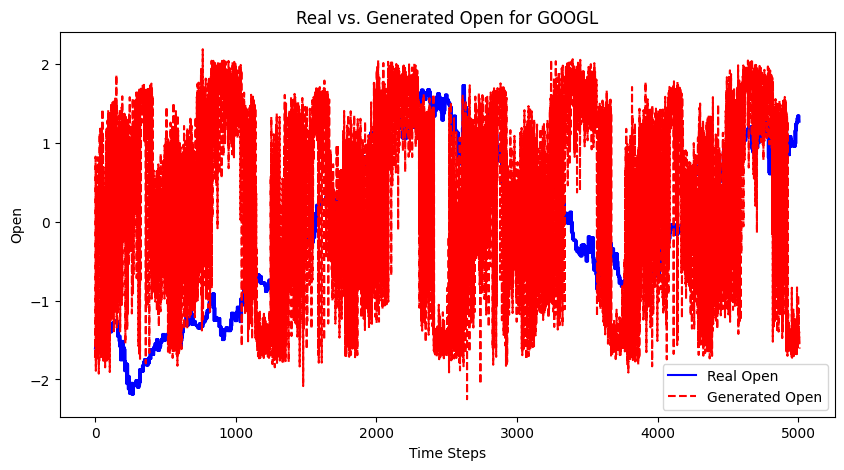

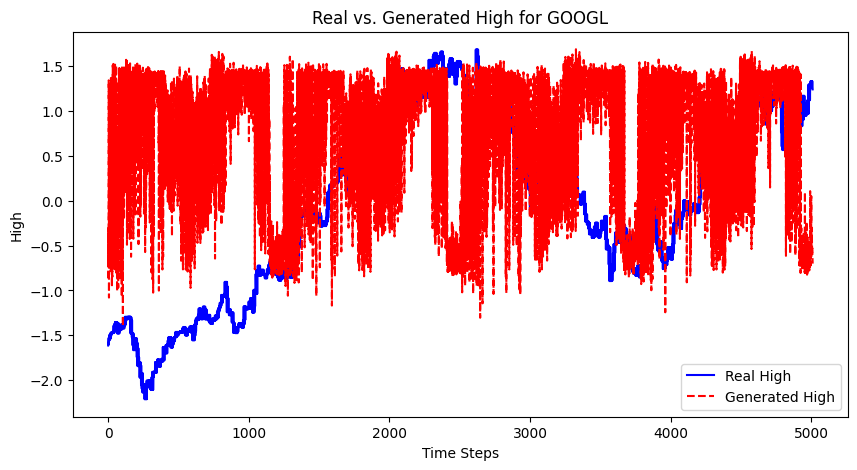

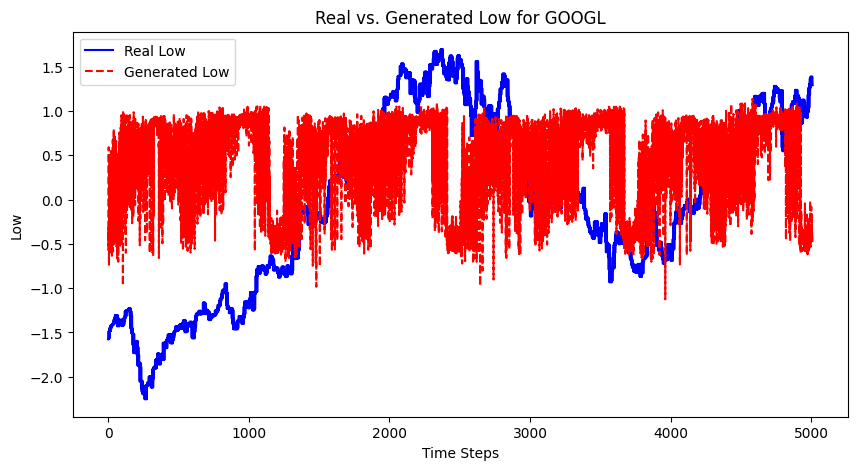

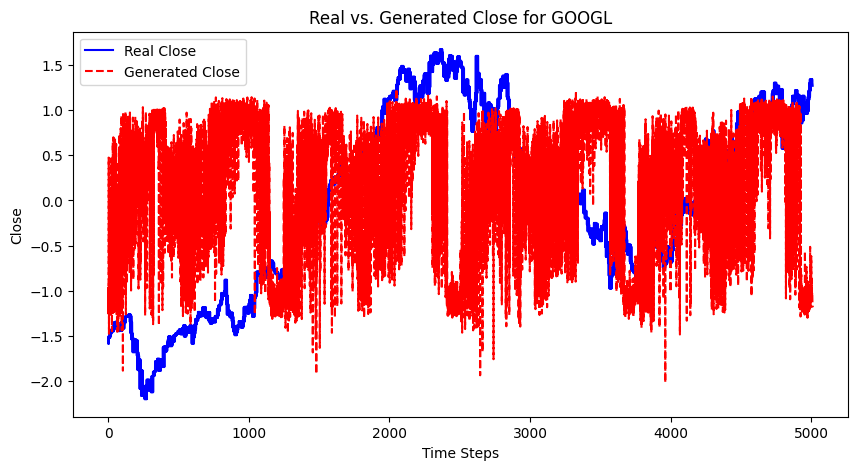

Mean Absolute Error for GOOGL:
  Open: 1.2870
  High: 1.1289
  Low: 0.9504
  Close: 0.9997


In [ ]:
def evaluate_model(generator, processed_data, config):
    generator.eval()  # Set generator to evaluation mode
    device = 'cpu'
    for ticker in config['tickers']:
        print(f"\nEvaluating for ticker: {ticker}")
        
        # Fetch processed real data
        real_data = processed_data[ticker]
        real_sequences = real_data['norm_ohlc']  # Normalized OHLC sequences
        date_info = real_data['date_info']       # Date information for each sequence
        ticker_id = torch.tensor([ticker_to_id[ticker]]).to(device)

        # Initialize arrays to hold real and generated data for comparison
        generated_sequences = []

        # Generate sequences
        with torch.no_grad():  # Disable gradients for evaluation
            for i in range(real_sequences.shape[0]):
                # Prepare inputs for the generator
                sequence_length, feature_dim = real_sequences.shape[1:]
                noise = torch.randn((1, sequence_length, feature_dim)).to(device)
                
                day_of_week = torch.tensor(date_info[i, :, 0]).unsqueeze(0).to(device)
                month = torch.tensor(date_info[i, :, 1]).unsqueeze(0).to(device)
                
                # Generate synthetic sequence
                generated_sequence = generator(noise, ticker_id, day_of_week, month)
                generated_sequences.append(generated_sequence.cpu().numpy())

        # Convert lists to numpy arrays for analysis
        generated_sequences = np.vstack(generated_sequences)
        real_sequences = real_sequences

        # Plot and compare real vs. generated data for each feature
        for idx, feature in enumerate(config['features']):
            plt.figure(figsize=(10, 5))
            plt.plot(real_sequences[:, :, idx].flatten(), label='Real ' + feature, color='blue')
            plt.plot(generated_sequences[:, :, idx].flatten(), label='Generated ' + feature, linestyle='--', color='red')
            plt.title(f'Real vs. Generated {feature} for {ticker}')
            plt.xlabel('Time Steps')
            plt.ylabel(feature)
            plt.legend()
            plt.show()
        
        # Calculate Mean Absolute Error for each feature
        mae = np.mean(np.abs(real_sequences - generated_sequences), axis=(0, 1))
        print(f"Mean Absolute Error for {ticker}:")
        for idx, feature in enumerate(config['features']):
            print(f"  {feature}: {mae[idx]:.4f}")
            
evaluate_model(generator, processed_data, config)

In [ ]:
config

{'tickers': ['AAPL', 'MSFT', 'GOOGL'],
 'start_date': '2020-01-01',
 'end_date': '2024-01-01',
 'sequence_length': 5,
 'features': ['Open', 'High', 'Low', 'Close'],
 'random_seed': 35,
 'd_model': 16,
 'n_heads': 1,
 'dropout': 0.1,
 'n_layers': 1,
 'batch_size': 32,
 'lr': 0.001,
 'epochs': 200,
 'max_day_of_week': 7,
 'max_month': 12,
 'print_interval': 30}

In [ ]:
import matplotlib.pyplot as plt

# Sample ticker ID and date information for comparison
sample_ticker_ids = torch.tensor([ticker_to_id[ticker] for ticker in config['tickers']])
day_of_week = torch.tensor(date_info[:, :, 0])  # Example of day of week info
month = torch.tensor(date_info[:, :, 1])        # Example of month info

# Generate synthetic data
with torch.no_grad():
    noise = torch.randn(sample_ticker_ids.size(0), config['sequence_length'], len(config['features']))
    generated_sequences = generator(noise, sample_ticker_ids, day_of_week, month)

# Denormalize generated and real sequences
for i, ticker in enumerate(config['tickers']):
    print(f"\nEvaluating Ticker: {ticker}")
    
    # Extract real sequences and normalization parameters
    real_norm_ohlc = processed_data[ticker]['norm_ohlc']
    real_norm_volume = processed_data[ticker]['norm_volume']
    norm_params = processed_data[ticker]['norm_params']
    
    # Generate equivalent real sequence for comparison
    real_sequence = real_norm_ohlc[i:i + 1]  # Fetch real data for the same range
    real_volume = real_norm_volume[i:i + 1]

    # Denormalize both real and generated data
    denorm_real_ohlc, denorm_real_volume = denormalize_stock_data(real_sequence, real_volume, norm_params)
    denorm_generated_ohlc, denorm_generated_volume = denormalize_stock_data(generated_sequences[i].unsqueeze(0), 
                                                                            real_volume, norm_params)

    # Plot and compare feature by feature
    features = config['features']
    for feature_idx, feature in enumerate(features):
        plt.figure(figsize=(10, 4))
        
        # Plot real vs. generated for each feature
        plt.plot(denorm_real_ohlc[0, :, feature_idx], label=f'Real {feature}', marker='o')
        plt.plot(denorm_generated_ohlc[0, :, feature_idx], label=f'Generated {feature}', marker='x')
        
        plt.title(f'{ticker} - Real vs Generated {feature}')
        plt.xlabel('Timestep')
        plt.ylabel('Value')
        plt.legend()
        plt.grid(True)
        plt.show()
    
    # Volume comparison
    plt.figure(figsize=(10, 4))
    plt.plot(denorm_real_volume[0], label='Real Volume', marker='o')
    plt.plot(denorm_generated_volume[0], label='Generated Volume', marker='x')
    
    plt.title(f'{ticker} - Real vs Generated Volume')
    plt.xlabel('Timestep')
    plt.ylabel('Volume')
    plt.legend()
    plt.grid(True)
    plt.show()


RuntimeError: The size of tensor a (5) must match the size of tensor b (3) at non-singleton dimension 1

In [ ]:
import math 

# Instantiate models with ticker embeddings
num_tickers = len(config['tickers'])
generator = TransformerGenerator(config, num_tickers)
discriminator = TransformerDiscriminator(config, num_tickers)

# Generate ticker IDs for the batch
batch_size = config['batch_size']
# ticker_ids = torch.tensor([ticker_to_id[ticker] for ticker in config['tickers'] for _ in range(batch_size // num_tickers)])

# Assume we have a batch of data with sequences and corresponding date information
ticker_ids = torch.tensor([ticker_to_id[ticker] for ticker in config['tickers']])
date_info = processed_data[ticker]['date_info']  # Example of extracting day and month data

# Extract day of week and month from the date_info structure
day_of_week = torch.tensor(date_info[:, :, 0])  # Shape: [batch_size, seq_length]
month = torch.tensor(date_info[:, :, 1])         # Shape: [batch_size, seq_length]


# Training loop with ticker embedding
for epoch in range(config['epochs']):
    # ---------------------
    #  Train Discriminator
    # ---------------------
    optimizer_D.zero_grad()

    # Train with real data
    real_sequences = torch.FloatTensor(all_sequences)
    real_labels = torch.ones(real_sequences.size(0), 1)
    
    # Real data with ticker IDs
    real_output = discriminator(real_sequences, ticker_ids)
    real_loss = adversarial_loss(real_output, real_labels)
    
    # Train with fake data
    noise = torch.randn(real_sequences.size(0), config['sequence_length'], config['d_model'])
    fake_sequences = generator(noise, ticker_ids)
    fake_labels = torch.zeros(real_sequences.size(0), 1)
    
    fake_output = discriminator(fake_sequences.detach(), ticker_ids)
    fake_loss = adversarial_loss(fake_output, fake_labels)
    
    # Total discriminator loss and update
    d_loss = (real_loss + fake_loss) / 2
    d_loss.backward()
    optimizer_D.step()
    
    # -----------------
    #  Train Generator
    # -----------------
    optimizer_G.zero_grad()
    
    # Try to fool the discriminator with fake data
    fake_output = discriminator(fake_sequences, ticker_ids)
    g_loss = adversarial_loss(fake_output, real_labels)
    
    g_loss.backward()
    optimizer_G.step()
    
    # Print loss for each epoch
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{config['epochs']}], D Loss: {d_loss.item():.4f}, G Loss: {g_loss.item():.4f}")


TypeError: TransformerDiscriminator.forward() missing 2 required positional arguments: 'day_of_week' and 'month'